# AI-Driven Age Prediction from Student Essays with Gemini

This notebook samples essays from the [PERSUADE 2.0 corpus](https://github.com/scrosseye/persuade_corpus_2.0) (Crossley et al., 2024) and uses the Gemini API to predict writer age/grade from linguistic patterns in the essays.

**Design:**
- **Filters:** Independent task only + native English speakers only (`ell_status == 'No'`) to remove task-type and L1 confounds
- **Group A:** 10 essays from **Grade 8** writers, sampled near the Grade 8 median word count
- **Group B:** 10 essays from **Grades 9–12** writers, sampled near that group's median word count
- Each essay is presented with a **meta prompt** that neutralizes topic-based age cues
- **4 questions** per essay, each as a separate self-contained API call:
  1. Is the writer over 13? (yes/no + brief reasoning)
  2. Is the writer over 18? (yes/no + brief reasoning)
  3. How old is the writer what grade are they in? (structured estimate)
  4. What linguistic features of the text led to this estimate? (free-form analysis)

## 1. Setup

In [ ]:
# Install if needed (uncomment)
# !pip install google-genai pandas matplotlib seaborn

In [14]:
import pandas as pd
import numpy as np
import time
import json
import warnings
from google import genai
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120


GEMINI_API_KEY = "REDACTED"
GEMINI_MODEL = "gemini-2.5-flash"
RANDOM_SEED = 42
SAMPLE_SIZE = 10


## 2. Load Data and Sample Essays

We filter to **Independent task** essays (using personal knowledge or experiences) written by **native English speakers** (`ell_status == 'No'`), then sample essays closest to the median word count for each group to control for essay length as a confound.

**Note:** Filtering to non-ELL significantly reduces Grade 12 (243 → 15 essays) and Grade 9 (13 → 11 essays). The Grades 9–12 sample pool remains adequate overall (~1,970 essays) but may underrepresent those two grades.

In [15]:
# Load and deduplicate to essay level
raw = pd.read_csv('persuade_corpus_2.0_train.csv', low_memory=False)

essay_cols = [
    'essay_id_comp', 'full_text', 'holistic_essay_score', 'task',
    'prompt_name', 'gender', 'grade_level', 'ell_status',
    'race_ethnicity', 'essay_word_count'
]
df = raw.drop_duplicates(subset='essay_id_comp')[essay_cols].copy()
df = df.dropna(subset=['grade_level'])
df['grade_level'] = df['grade_level'].astype(int)
print(f'Total essays with grade level: {len(df):,}')

# Filter: Independent task only
df = df[df['task'] == 'Independent']
print(f'After filtering to Independent task: {len(df):,}')

# Filter: Native English speakers only (ELL = No)
df = df[df['ell_status'] == 'No']
print(f'After filtering to non-ELL: {len(df):,}')

# Show remaining grade distribution
print('\nFiltered grade distribution:')
print(df.groupby('grade_level').size().to_frame('count').assign(
    pct=lambda x: (x['count'] / x['count'].sum() * 100).round(1)
))

Total essays with grade level: 14,893
After filtering to Independent task: 7,168
After filtering to non-ELL: 6,539

Filtered grade distribution:
             count   pct
grade_level             
8             4566  69.8
9               11   0.2
10             241   3.7
11            1706  26.1
12              15   0.2


In [16]:
def sample_near_median(group_df, n, seed):
    """Sample n essays closest to the group's median word count.
    
    If there are more than n essays at exactly the median distance,
    we randomly sample from those ties to avoid deterministic bias.
    """
    median_wc = group_df['essay_word_count'].median()
    group_df = group_df.copy()
    group_df['dist_from_median'] = (group_df['essay_word_count'] - median_wc).abs()
    group_df = group_df.sort_values('dist_from_median')
    
    # Take the closest n, with random tie-breaking
    cutoff_dist = group_df.iloc[min(n-1, len(group_df)-1)]['dist_from_median']
    within_cutoff = group_df[group_df['dist_from_median'] <= cutoff_dist]
    
    if len(within_cutoff) > n:
        sampled = within_cutoff.sample(n=n, random_state=seed)
    else:
        sampled = within_cutoff.head(n)
    
    return sampled.drop(columns=['dist_from_median'])

# Group A: Grade 8
g8 = df[df['grade_level'] == 8]
sample_g8 = sample_near_median(g8, SAMPLE_SIZE, RANDOM_SEED)
sample_g8['group'] = 'Grade 8'

# Group B: Grades 9-12
g912 = df[df['grade_level'].isin([9, 10, 11, 12])]
sample_g912 = sample_near_median(g912, SAMPLE_SIZE, RANDOM_SEED)
sample_g912['group'] = 'Grades 9-12'

# Combine
sample_df = pd.concat([sample_g8, sample_g912], ignore_index=True)

print(f'Grade 8 sample: {len(sample_g8)} essays, '
      f'median WC = {g8["essay_word_count"].median():.0f}, '
      f'sample WC range = {sample_g8["essay_word_count"].min()}-{sample_g8["essay_word_count"].max()}')
print(f'Grades 9-12 sample: {len(sample_g912)} essays, '
      f'median WC = {g912["essay_word_count"].median():.0f}, '
      f'sample WC range = {sample_g912["essay_word_count"].min()}-{sample_g912["essay_word_count"].max()}')
print()
print('Sampled essays:')
display(sample_df[['essay_id_comp', 'group', 'grade_level', 'essay_word_count', 
                    'prompt_name', 'gender', 'holistic_essay_score']].reset_index(drop=True))

Grade 8 sample: 10 essays, median WC = 360, sample WC range = 360-360
Grades 9-12 sample: 10 essays, median WC = 601, sample WC range = 600-602

Sampled essays:


,essay_id_comp,group,grade_level,essay_word_count,prompt_name,gender,holistic_essay_score
0,10B79C092DE1,Grade 8,8,360,Seeking multiple opinions,M,4
1,AE021F85F4D5,Grade 8,8,360,Community service,F,4
2,CE04D4F7AFFA,Grade 8,8,360,Seeking multiple opinions,M,3
3,2C1BB6C07105,Grade 8,8,360,Cell phones at school,F,3
4,A222B298A2BF,Grade 8,8,360,Mandatory extracurricular activities,F,3
5,24B659FCEC04,Grade 8,8,360,Grades for extracurricular activities,F,4
6,16760A114ACB,Grade 8,8,360,Seeking multiple opinions,F,4
7,2A79C81E7B71,Grade 8,8,360,Seeking multiple opinions,F,4
8,185B843FA452,Grade 8,8,360,Cell phones at school,M,3
9,C044BD1DAC0E,Grade 8,8,360,Cell phones at school,M,3


## 3. Define Prompts and Gemini Query Function

Each API call is self-contained: **meta prompt + full essay + question**. The meta prompt neutralizes topic-based age cues since prompts are confounded with grade level in this corpus.

In [17]:
# Initialize Gemini client (new google-genai SDK)
client = genai.Client(api_key=GEMINI_API_KEY)

def query_gemini(prompt: str) -> str:
    """Generate a response from Gemini."""
    try:
        response = client.models.generate_content(
            model=GEMINI_MODEL,
            contents=prompt
        )
        return response.text.strip()
    except Exception as e:
        return f"ERROR: {str(e)}"

print(f"Gemini client ready ({GEMINI_MODEL}).")

Gemini client ready (gemini-2.5-flash).


In [18]:
# Meta prompt to neutralize topic-based age cues
META_PROMPT = (
    "This essay is written in response to a prompt, so the topic choice "
    "does not reflect the author's age."
)

# The 4 questions with response format guidance
QUESTIONS = {
    'q1_over_13': {
        'question': (
            "Based solely on the linguistic features, writing style, and "
            "developmental markers in this essay, is the writer over 13 years old?\n\n"
            "Respond with YES or NO, followed by a brief one-sentence reasoning."
        ),
        'label': 'Over 13?'
    },
    'q2_over_18': {
        'question': (
            "Based solely on the linguistic features, writing style, and "
            "developmental markers in this essay, is the writer over 18 years old?\n\n"
            "Respond with YES or NO, followed by a brief one-sentence reasoning."
        ),
        'label': 'Over 18?'
    },
    'q3_age_grade': {
        'question': (
            "Based solely on the linguistic features, writing style, and "
            "developmental markers in this essay, estimate the writer's age and "
            "school grade level.\n\n"
            "Respond in this format:\n"
            "Estimated age: [number]\n"
            "Estimated grade: [number]\n"
            "Confidence: [low/medium/high]\n"
            "Brief reasoning: [one sentence]"
        ),
        'label': 'Age & grade estimate'
    },
    'q4_features': {
        'question': (
            "Based solely on the linguistic features, writing style, and "
            "developmental markers in this essay, what specific features of the "
            "text lead you to your estimate of the writer's age and grade level?\n\n"
            "Discuss features such as: vocabulary sophistication, sentence complexity, "
            "argument structure, use of transitions, spelling/grammar patterns, "
            "and any other relevant developmental markers."
        ),
        'label': 'Feature analysis'
    }
}

def build_prompt(essay_text: str, question: str) -> str:
    """Build a self-contained prompt: meta context + essay + question."""
    return (
        f"{META_PROMPT}\n\n"
        f"--- ESSAY ---\n"
        f"{essay_text}\n"
        f"--- END OF ESSAY ---\n\n"
        f"{question}"
    )

print(f"Defined {len(QUESTIONS)} questions per essay.")
print(f"Total API calls needed: {len(sample_df)} essays × {len(QUESTIONS)} questions = {len(sample_df) * len(QUESTIONS)}")

Defined 4 questions per essay.
Total API calls needed: 20 essays × 4 questions = 80


## 4. Run Gemini Queries

Each essay gets 4 independent API calls. Results are stored in a structured DataFrame.

In [19]:
# Run all queries
results = []

for idx, row in sample_df.iterrows():
    essay_num = idx + 1
    print(f"\n[{essay_num}/{len(sample_df)}] {row['group']} | "
          f"Grade {row['grade_level']} | {row['essay_word_count']} words | "
          f"{row['essay_id_comp']}")
    
    essay_result = {
        'essay_id_comp': row['essay_id_comp'],
        'group': row['group'],
        'actual_grade': row['grade_level'],
        'word_count': row['essay_word_count'],
        'prompt_name': row['prompt_name'],
        'gender': row['gender'],
        'holistic_score': row['holistic_essay_score'],
    }
    
    for q_key, q_info in QUESTIONS.items():
        prompt = build_prompt(row['full_text'], q_info['question'])
        print(f"  → {q_info['label']}...", end=' ')
        response = query_gemini(prompt)
        essay_result[q_key] = response
        print("✓")
        time.sleep(1.0)  # Rate limiting
    
    results.append(essay_result)

results_df = pd.DataFrame(results)
print(f"\n{'=' * 60}")
print(f"Complete: {len(results_df)} essays × {len(QUESTIONS)} questions = "
      f"{len(results_df) * len(QUESTIONS)} API calls")


[1/20] Grade 8 | Grade 8 | 360 words | 10B79C092DE1
  → Over 13?... ✓
  → Over 18?... ✓
  → Age & grade estimate... ✓
  → Feature analysis... ✓

[2/20] Grade 8 | Grade 8 | 360 words | AE021F85F4D5
  → Over 13?... ✓
  → Over 18?... ✓
  → Age & grade estimate... ✓
  → Feature analysis... ✓

[3/20] Grade 8 | Grade 8 | 360 words | CE04D4F7AFFA
  → Over 13?... ✓
  → Over 18?... ✓
  → Age & grade estimate... ✓
  → Feature analysis... ✓

[4/20] Grade 8 | Grade 8 | 360 words | 2C1BB6C07105
  → Over 13?... ✓
  → Over 18?... ✓
  → Age & grade estimate... ✓
  → Feature analysis... ✓

[5/20] Grade 8 | Grade 8 | 360 words | A222B298A2BF
  → Over 13?... ✓
  → Over 18?... ✓
  → Age & grade estimate... ✓
  → Feature analysis... ✓

[6/20] Grade 8 | Grade 8 | 360 words | 24B659FCEC04
  → Over 13?... ✓
  → Over 18?... ✓
  → Age & grade estimate... ✓
  → Feature analysis... ✓

[7/20] Grade 8 | Grade 8 | 360 words | 16760A114ACB
  → Over 13?... ✓
  → Over 18?... ✓
  → Age & grade estimate... ✓
  → Feature

## 5. View Raw Responses

In [20]:
# Display responses for each essay
for idx, row in results_df.iterrows():
    print(f"\n{'=' * 70}")
    print(f"Essay {idx+1}: {row['group']} | Actual Grade {row['actual_grade']} | "
          f"{row['word_count']} words | Score {row['holistic_score']}")
    print(f"Prompt: {row['prompt_name']}")
    print(f"{'=' * 70}")
    
    for q_key, q_info in QUESTIONS.items():
        print(f"\n  [{q_info['label']}]")
        print(f"  {row[q_key]}")
    print()


Essay 1: Grade 8 | Actual Grade 8 | 360 words | Score 4
Prompt: Seeking multiple opinions

  [Over 13?]
  NO. The significant repetition of ideas and phrases, alongside consistent grammatical errors like "your/you're" and "their/they're," suggests a writer still developing their command of academic essay structure and conventional grammar, which is more typical of a writer around or under 13 years old.

  [Over 18?]
  NO.

The essay exhibits several developmental markers such as persistent grammatical errors with homophones (e.g., "what *their* trying to decide," "what *your* trying to decide," "when *your* in a tough spot"), significant repetition of ideas and even entire sentences, and a relatively simplistic development of arguments without much nuance or deeper exploration, which are more characteristic of an adolescent writer.

  [Age & grade estimate]
  Estimated age: 12
Estimated grade: 7
Confidence: High
Brief reasoning: The essay demonstrates a clear organizational structure 

## 6. Parse and Evaluate Predictions

We extract structured predictions from the LLM responses and compare them to actual grade levels.

In [21]:
import re

def parse_yes_no(response):
    """Extract YES/NO from a response."""
    response_upper = response.strip().upper()
    if response_upper.startswith('YES'):
        return 'YES'
    elif response_upper.startswith('NO'):
        return 'NO'
    # Check for YES/NO anywhere in first line
    first_line = response_upper.split('\n')[0]
    if 'YES' in first_line and 'NO' not in first_line:
        return 'YES'
    elif 'NO' in first_line and 'YES' not in first_line:
        return 'NO'
    return 'UNCLEAR'

def parse_estimated_grade(response):
    """Extract estimated grade from Q3 response."""
    match = re.search(r'[Ee]stimated\s+[Gg]rade[:\s]+(\d+)', response)
    if match:
        return int(match.group(1))
    return None

def parse_estimated_age(response):
    """Extract estimated age from Q3 response."""
    match = re.search(r'[Ee]stimated\s+[Aa]ge[:\s]+(\d+)', response)
    if match:
        return int(match.group(1))
    return None

# Parse all responses
results_df['pred_over_13'] = results_df['q1_over_13'].apply(parse_yes_no)
results_df['pred_over_18'] = results_df['q2_over_18'].apply(parse_yes_no)
results_df['pred_grade'] = results_df['q3_age_grade'].apply(parse_estimated_grade)
results_df['pred_age'] = results_df['q3_age_grade'].apply(parse_estimated_age)

# Ground truth
results_df['actual_over_13'] = (results_df['actual_grade'] >= 9).map({True: 'YES', False: 'NO'})
# Grade 8 = typically 13-14, so could be either. Grades 9+ are definitively over 13.
# For simplicity: Grade 8 students are typically 13-14, so borderline.
# We'll flag this in the analysis.

results_df['actual_over_18'] = 'NO'  # All students are in grades 8-12 (minors)

# Display parsed predictions
display_cols = ['group', 'actual_grade', 'word_count', 'pred_over_13', 
                'pred_over_18', 'pred_age', 'pred_grade']
display(results_df[display_cols])

,group,actual_grade,word_count,pred_over_13,pred_over_18,pred_age,pred_grade
0,Grade 8,8,360,NO,NO,12,7
1,Grade 8,8,360,NO,NO,12,7
2,Grade 8,8,360,NO,NO,12,7
3,Grade 8,8,360,NO,NO,11,6
4,Grade 8,8,360,NO,NO,11,6
5,Grade 8,8,360,NO,NO,11,6
6,Grade 8,8,360,NO,NO,13,8
7,Grade 8,8,360,NO,NO,13,7
8,Grade 8,8,360,NO,NO,12,7
9,Grade 8,8,360,NO,NO,12,7


## 7. Summary Analysis

In [22]:
# Q1: Over 13 accuracy
print("Q1: 'Is the writer over 13?'")
print("-" * 40)
for group in ['Grade 8', 'Grades 9-12']:
    sub = results_df[results_df['group'] == group]
    yes_count = (sub['pred_over_13'] == 'YES').sum()
    print(f"  {group}: {yes_count}/{len(sub)} predicted YES")
print()

# Q2: Over 18 accuracy
print("Q2: 'Is the writer over 18?'")
print("-" * 40)
for group in ['Grade 8', 'Grades 9-12']:
    sub = results_df[results_df['group'] == group]
    yes_count = (sub['pred_over_18'] == 'YES').sum()
    correct = (sub['pred_over_18'] == 'NO').sum()  # All are minors
    print(f"  {group}: {yes_count}/{len(sub)} predicted YES "
          f"(correct answer is NO for all — {correct}/{len(sub)} correct)")
print()

# Q3: Grade prediction error
print("Q3: Grade prediction accuracy")
print("-" * 40)
valid = results_df.dropna(subset=['pred_grade'])
if len(valid) > 0:
    valid = valid.copy()
    valid['grade_error'] = valid['pred_grade'] - valid['actual_grade']
    
    for group in ['Grade 8', 'Grades 9-12']:
        sub = valid[valid['group'] == group]
        if len(sub) > 0:
            mae = sub['grade_error'].abs().mean()
            mean_err = sub['grade_error'].mean()
            exact = (sub['grade_error'] == 0).sum()
            within_1 = (sub['grade_error'].abs() <= 1).sum()
            print(f"  {group} (n={len(sub)}):")
            print(f"    Mean Absolute Error: {mae:.1f} grades")
            print(f"    Mean Signed Error:   {mean_err:+.1f} grades (positive = overestimate)")
            print(f"    Exact match:         {exact}/{len(sub)}")
            print(f"    Within ±1 grade:     {within_1}/{len(sub)}")
else:
    print("  Could not parse grade predictions from responses.")

Q1: 'Is the writer over 13?'
----------------------------------------
  Grade 8: 0/10 predicted YES
  Grades 9-12: 6/10 predicted YES

Q2: 'Is the writer over 18?'
----------------------------------------
  Grade 8: 0/10 predicted YES (correct answer is NO for all — 10/10 correct)
  Grades 9-12: 0/10 predicted YES (correct answer is NO for all — 10/10 correct)

Q3: Grade prediction accuracy
----------------------------------------
  Grade 8 (n=10):
    Mean Absolute Error: 1.2 grades
    Mean Signed Error:   -1.2 grades (positive = overestimate)
    Exact match:         1/10
    Within ±1 grade:     7/10
  Grades 9-12 (n=10):
    Mean Absolute Error: 2.3 grades
    Mean Signed Error:   -2.3 grades (positive = overestimate)
    Exact match:         0/10
    Within ±1 grade:     1/10


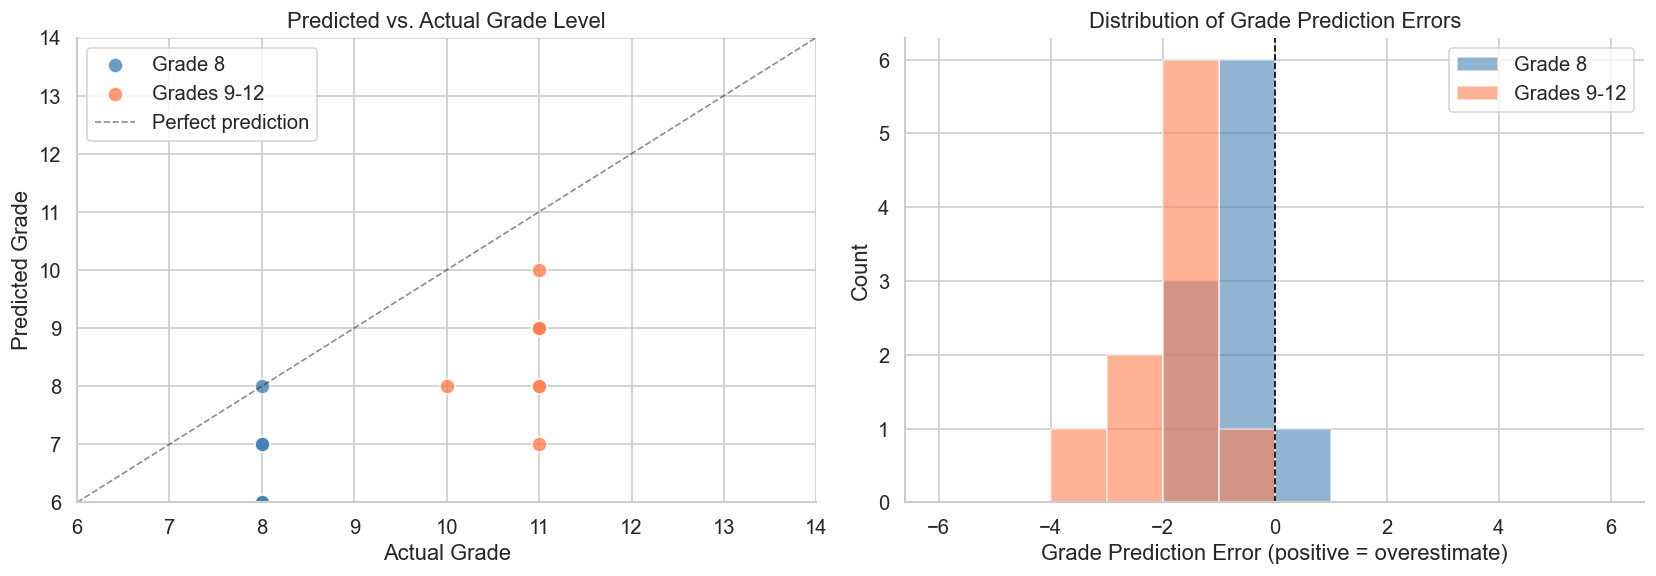

In [23]:
# Visualization: Predicted vs Actual Grade
valid = results_df.dropna(subset=['pred_grade']).copy()

if len(valid) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter: predicted vs actual
    colors = {'Grade 8': 'steelblue', 'Grades 9-12': 'coral'}
    for group, color in colors.items():
        sub = valid[valid['group'] == group]
        axes[0].scatter(sub['actual_grade'], sub['pred_grade'],
                       c=color, label=group, s=80, edgecolor='white', alpha=0.8)
    axes[0].plot([6, 14], [6, 14], 'k--', lw=1, alpha=0.5, label='Perfect prediction')
    axes[0].set_xlabel('Actual Grade')
    axes[0].set_ylabel('Predicted Grade')
    axes[0].set_title('Predicted vs. Actual Grade Level')
    axes[0].legend()
    axes[0].set_xlim(6, 14)
    axes[0].set_ylim(6, 14)
    
    # Error distribution
    valid['grade_error'] = valid['pred_grade'] - valid['actual_grade']
    for group, color in colors.items():
        sub = valid[valid['group'] == group]
        axes[1].hist(sub['grade_error'], bins=range(-6, 7), alpha=0.6,
                    color=color, label=group, edgecolor='white')
    axes[1].axvline(x=0, color='black', linestyle='--', lw=1)
    axes[1].set_xlabel('Grade Prediction Error (positive = overestimate)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Distribution of Grade Prediction Errors')
    axes[1].legend()
    
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("No valid grade predictions to plot.")

## 8. Save Results

In [ ]:
# Save full results to CSV for later analysis
output_path = 'gemini_age_prediction_results.csv'
results_df.to_csv(output_path, index=False)
print(f"Results saved to {output_path}")
print(f"Columns: {list(results_df.columns)}")

## 9. Feature Analysis Summary

Print the Q4 feature analyses for qualitative review.

In [13]:
for idx, row in results_df.iterrows():
    print(f"\n{'=' * 70}")
    print(f"Essay {idx+1}: {row['group']} | Actual Grade {row['actual_grade']} "
          f"| Predicted Grade {row.get('pred_grade', 'N/A')}")
    print(f"{'=' * 70}")
    print(row['q4_features'])
    print()


Essay 1: Grade 8 | Actual Grade 8 | Predicted Grade 7
Based solely on the linguistic features, writing style, and developmental markers in this essay, I would estimate the writer to be in **Grade 6 or early Grade 7**, likely around **11-12 years old**.

Here's a breakdown of the specific features that lead to this estimate:

1.  **Vocabulary Sophistication:**
    *   **Features:** The vocabulary is generally basic and common ("opinion," "solution," "important," "difficult," "problem," "help").
    *   **Developmental Marker:** While words like "biased," "comprehend," "dilemma," and "resolution" appear, they are not used with great nuance. The most telling feature is the repeated misuse of "amplitude" ("amplitude of the problem," "problem of higher amplitude") where "magnitude," "severity," or "importance" would be correct. This indicates a writer attempting to use more sophisticated vocabulary but not yet fully understanding its meaning or appropriate context, a common stage in middle